<a href="https://colab.research.google.com/github/shahwaiz-9/Deep-Learning/blob/main/GoogleNet_Depth_Analysis_(_CNN_).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model Importing and predicting results



In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model


model = InceptionV3(weights='imagenet', include_top=True)


img_path = '/content/0O4A8329.jpg'
img = image.load_img(img_path, target_size=(299, 299))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

successive_outputs = [layer.output for layer in model.layers if 'conv' in layer.name or 'concat' in layer.name]
visualization_model = Model(inputs=model.input, outputs=successive_outputs)


successive_feature_maps = visualization_model.predict(x)

# 5. Retrieve the names of the layers for labels
layer_names = [layer.name for layer in model.layers if 'conv' in layer.name or 'concat' in layer.name]

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


Plotting results after each layers mainly divided into 3 groups



In [4]:
def plot_feature_maps(layer_name, feature_map):
    n_features = 8 # Displaying 8 channels
    size = feature_map.shape[1]
    display_grid = np.zeros((size, size * n_features))

    for i in range(n_features):
        x = feature_map[0, :, :, i]
        # Standardize for visibility
        x -= x.mean(); x /= (x.std() + 1e-5); x *= 64; x += 128
        x = np.clip(x, 0, 255).astype('uint8')
        display_grid[:, i * size : (i + 1) * size] = x

    plt.figure(figsize=(15, 3))
    plt.title(layer_name)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')
    plt.axis('off')
    plt.show()

These are the very first layers. They act like high-pass filters, finding where colors change abruptly.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step
--- VISUALIZING THE STEM: EDGES AND LINES ---


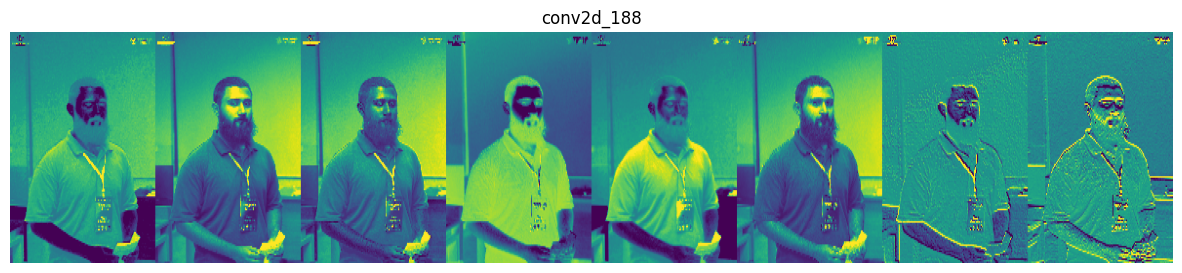

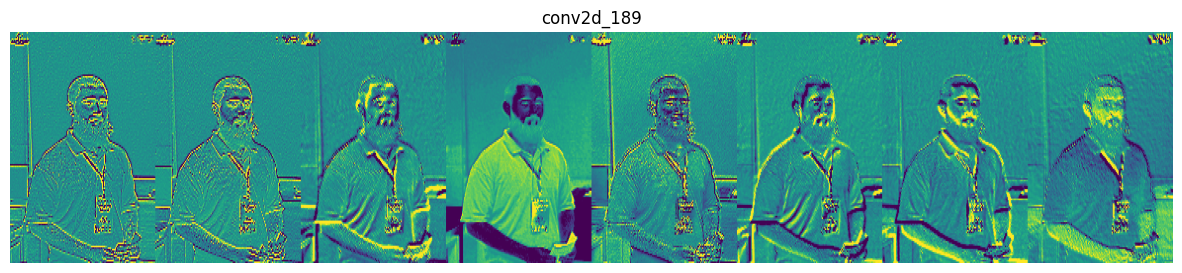

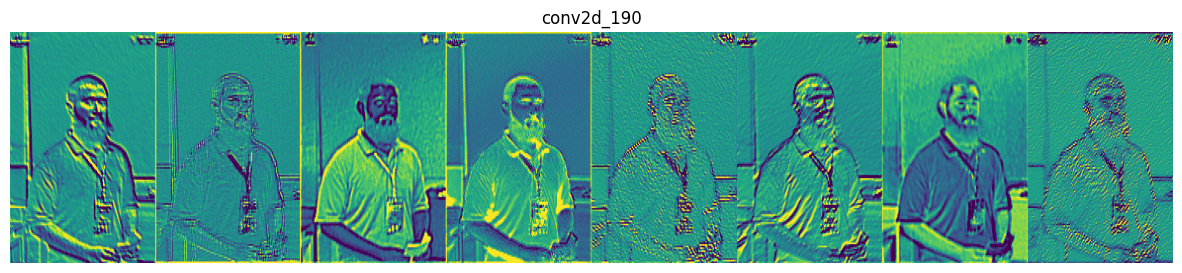

In [5]:
# Group 1: The Stem (Layers 0 to 10)
stem_layers = [layer.name for layer in model.layers[:11] if 'conv' in layer.name]
stem_outputs = [model.get_layer(name).output for name in stem_layers]
stem_viz_model = Model(inputs=model.input, outputs=stem_outputs)

stem_maps = stem_viz_model.predict(x)

print("--- VISUALIZING THE STEM: EDGES AND LINES ---")
for name, f_map in zip(stem_layers, stem_maps):
    # Use your plotting logic here (displaying first 8 channels)
    # You will see outlines of the person/object clearly.
    plot_feature_maps(name, f_map)

These layers (around mixed0 to mixed2) combine edges into patterns. If your image has a striped shirt or a brick wall, these layers will "glow."

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
--- VISUALIZING INCEPTION A: TEXTURES AND PATTERNS ---


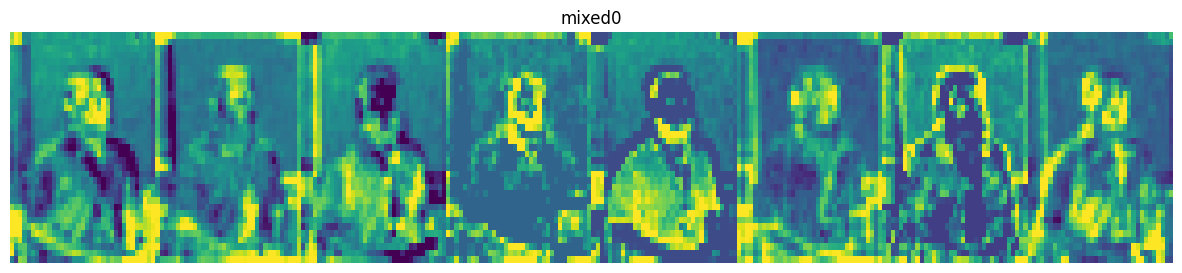

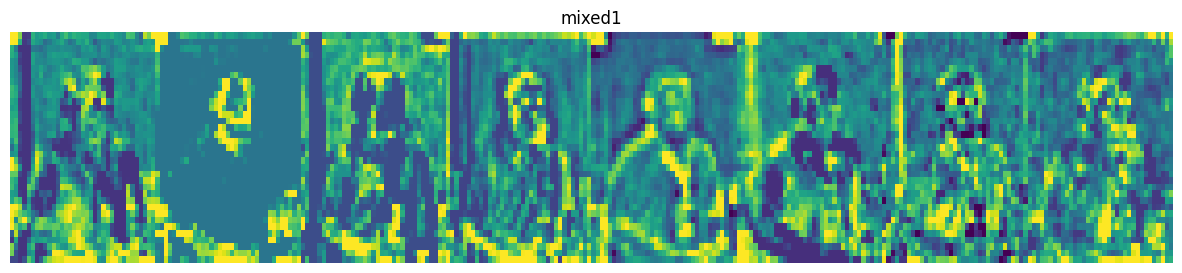

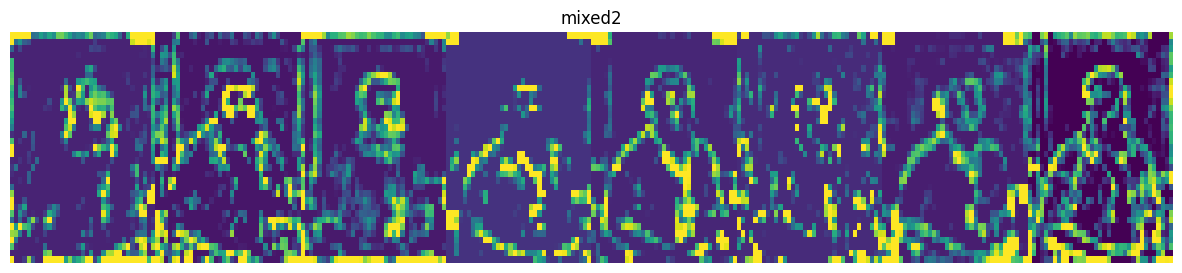

In [6]:
# Group 2: Inception A (Early blocks)
inc_a_layers = ['mixed0', 'mixed1', 'mixed2']
inc_a_outputs = [model.get_layer(name).output for name in inc_a_layers]
inc_a_viz_model = Model(inputs=model.input, outputs=inc_a_outputs)

inc_a_maps = inc_a_viz_model.predict(x)

print("--- VISUALIZING INCEPTION A: TEXTURES AND PATTERNS ---")
for name, f_map in zip(inc_a_layers, inc_a_maps):
    # Notice the image getting more abstract and "pattern-oriented"
    plot_feature_maps(name, f_map)

This is the "Face/Hands/T-shirt" stage. These layers (mixed3 to mixed7) are much smaller in resolution ($17 \times 17$). They look for complex parts of a human or object.

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
--- VISUALIZING INCEPTION B/C: SPECIALIZED PARTS ---


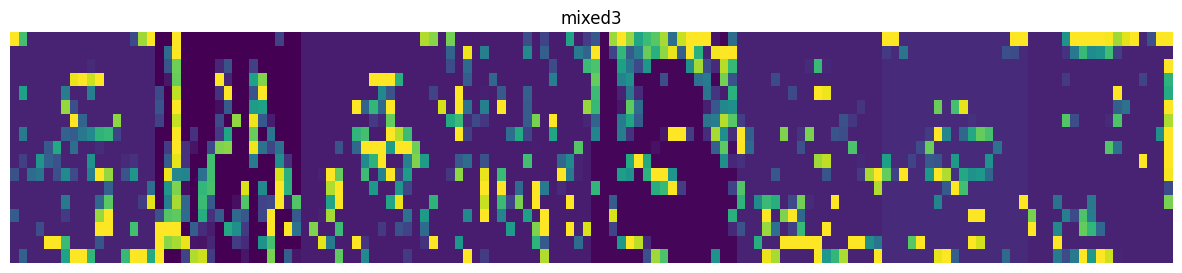

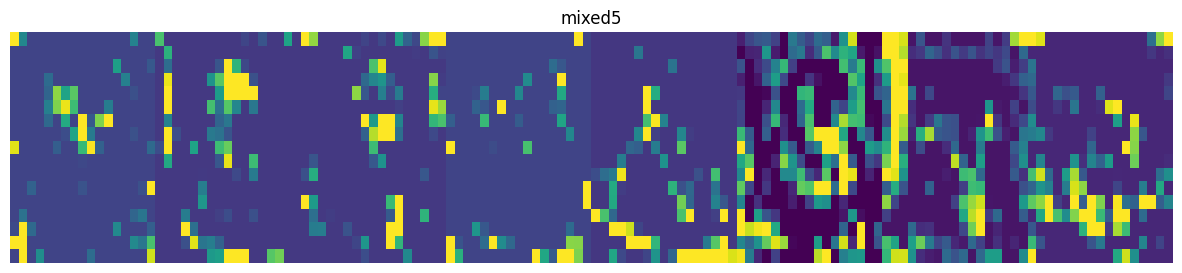

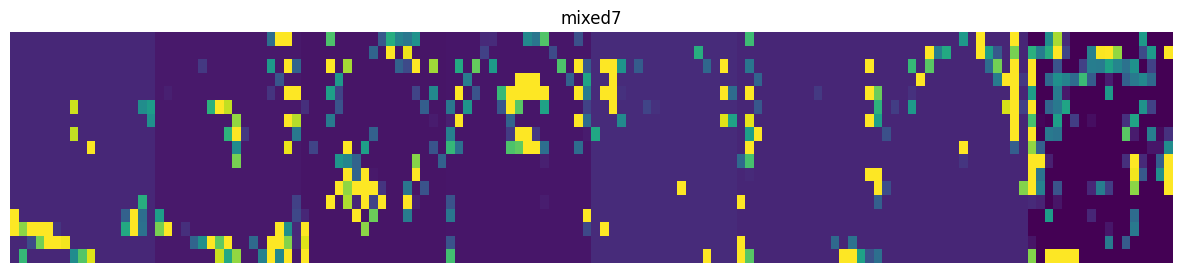

In [7]:
# Group 3: Inception B/C (Middle blocks)
inc_bc_layers = ['mixed3', 'mixed5', 'mixed7']
inc_bc_outputs = [model.get_layer(name).output for name in inc_bc_layers]
inc_bc_viz_model = Model(inputs=model.input, outputs=inc_bc_outputs)

inc_bc_maps = inc_bc_viz_model.predict(x)

print("--- VISUALIZING INCEPTION B/C: SPECIALIZED PARTS ---")
for name, f_map in zip(inc_bc_layers, inc_bc_maps):
    # You'll see specific blobs for eyes, limbs, or clothing items.
    plot_feature_maps(name, f_map)

Key Observations
1. We see the image visuls gets lost after group 2. This is classic conversion of Humans to machine understanding. At start we can see the image and make predictions but Machine isn't able to understand it. After some training we cannot understand the image but machine can IRONIC RELATION.

2. In the end there are 2048 feature maps stacked on top of each other. Basically our image information is divided into 2048 parts each acquiring single information like Ear , Nose in case of human.

3. How ANN approach this stuff. As humans what our perception will be when we see an human image?
   We will observe the facial information like ears, face , clothes etc and on the basis of this we will make prediction. The ANN part does the same. CNN part gives facial information to ANN and ANN predicts on the basis of this information.